In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [3]:
file = pd.read_csv("height_weight_dataset.csv")

In [4]:
file.head()

,Height_cm,Weight_kg
0,175.0,55.6
1,168.6,45.0
2,176.5,47.9
3,185.2,60.0
4,167.7,47.7


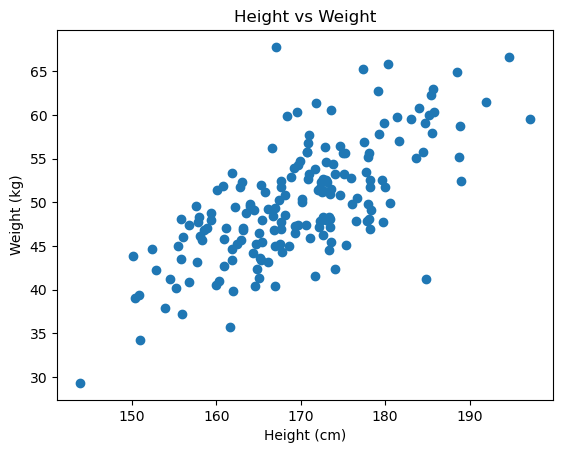

In [5]:
plt.scatter(file["Height_cm"],file["Weight_kg"])
plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.title("Height vs Weight")
plt.show()

In [6]:
file.corr()

,Height_cm,Weight_kg
Height_cm,1.000000,0.694144
Weight_kg,0.694144,1.000000


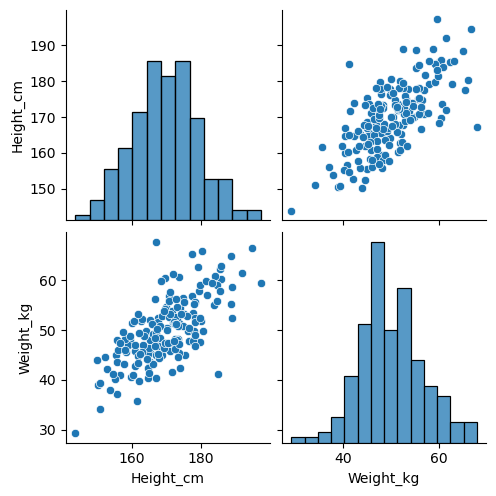

In [7]:
sns.pairplot(file)

<Axes: >

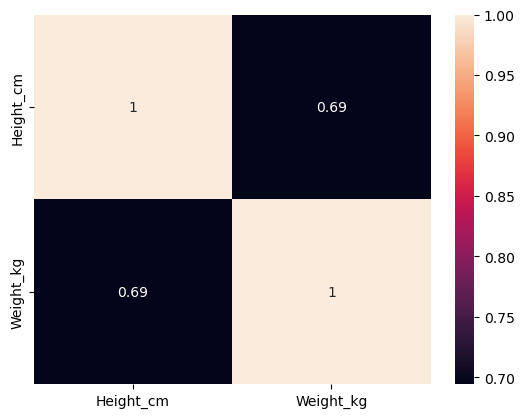

In [8]:
sns.heatmap(file.corr(), annot = True )

In [9]:
X = file[["Weight_kg"]]
y = file["Height_cm"]

In [10]:
X_train , X_test , y_train, y_test = train_test_split(X , y , test_size = 0.25)

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
# apply linear regression
regression = LinearRegression(n_jobs=-1)
regression.fit(X_train_scaled,y_train)

LinearRegression(n_jobs=-1)

In [13]:
regression.coef_

array([6.42856774])

In [14]:
regression.intercept_

169.0214814814815

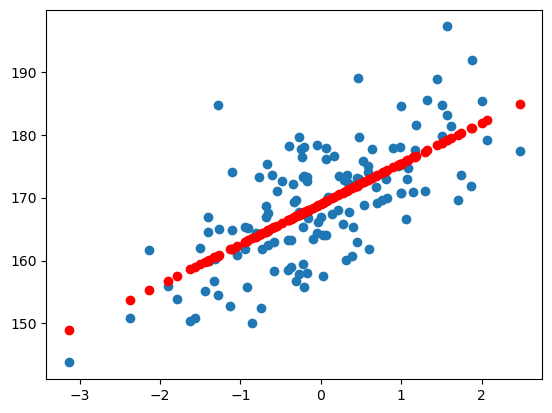

In [15]:
# plot the best fit line 
plt.scatter(X_train_scaled,y_train)
plt.scatter(X_train_scaled,regression.predict(X_train_scaled),color = "red")

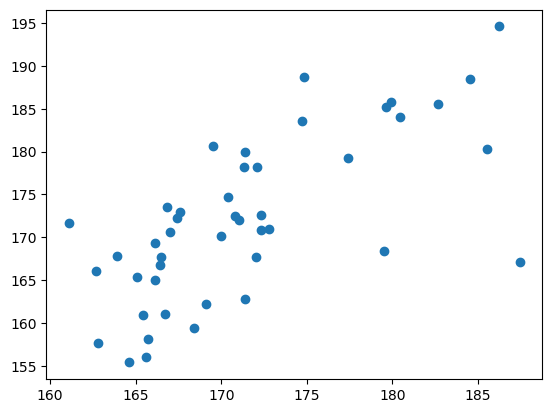

In [16]:
# prediction for test data 
y_pred = regression.predict(X_test_scaled)
plt.scatter(y_pred, y_test)

In [17]:
# performance metrics 
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score

In [18]:
mse = mean_squared_error(y_test , y_pred)
mse

47.08035168326467

In [19]:
mae = mean_absolute_error(y_test , y_pred)
mae

5.5552782685355595

In [20]:
rmse = np.sqrt(mse)
rmse

6.861512346652498

In [21]:
# r2 score
score = r2_score(y_test , y_pred)
score

0.4716816323965738

In [22]:
# adjusted r2 score 
score_1 = 1 - (1 - score)*(len(y_test) - 1 )/(len(y_test) - X_test.shape[1] -1)
score_1

0.4593951587313778

OLS LINEAR REGRESSION

In [23]:
import statsmodels.api as sm

In [24]:
model = sm.OLS(y_train , X_train).fit()
prediction = model.predict(X_test)
print(prediction)


151    159.566300
54     222.784304
108    178.159830
153    161.594685
112    160.242428
150    173.088867
170    159.228236
113    225.150753
67     175.117253
18     154.833401
104    202.500452
29     229.207524
137    158.214043
115    162.270813
99     158.552107
156    186.611435
80     149.762438
78     178.159830
5      177.145638
139    146.043732
39     173.764996
65     186.273371
75     174.779188
132    164.975327
98     170.384354
95     152.128887
3      202.838517
45     175.117253
122    205.543030
55     195.401104
6      203.852709
128    179.850151
158    155.847594
41     140.296641
47     168.694033
109    157.199850
73     212.980442
123    155.509529
94     145.705668
136    167.341776
31     219.403662
34     177.483702
157    171.736611
10     153.819208
129    157.199850
dtype: float64


In [25]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:              Height_cm   R-squared (uncentered):                   0.990
Model:                            OLS   Adj. R-squared (uncentered):              0.990
Method:                 Least Squares   F-statistic:                          1.340e+04
Date:                Fri, 10 Apr 2026   Prob (F-statistic):                   3.52e-136
Time:                        14:32:32   Log-Likelihood:                         -572.79
No. Observations:                 135   AIC:                                      1148.
Df Residuals:                     134   BIC:                                      1150.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

### New data Prediction

In [26]:
value = float(input("Enter the weight to predict the height : "))
regression.predict(scaler.transform([[value]]))

c:\Users\ASHVITA\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([288.66009878])